## 1. Introduction

This notebook focuses on **Step 4 - Learning Rate Optimization**, where we aim to find the optimal learning rate for our top-performing models. We will apply a learning rate scheduler to gradually increase the learning rate during training, starting from a very low value and increasing exponentially up to approximately 2.54.

### Objective:
- **Exponential Learning Rate Increase**: Start training with a very low learning rate (0.00001) and gradually increase it throughout the epochs until it reaches approximately 2.54.
- **Evaluate Performance**: Analyze the loss, accuracy, and F1-Score Weighted curves across epochs to identify the optimal learning rate that minimizes the loss while optimizing for class imbalance using F1-Score Weighted.
- **Ensure Stability**: This method helps identify the learning rate that achieves the best convergence without causing overfitting or underfitting.

For more details on the methodology, refer to [this article](https://towardsdatascience.com/how-to-optimize-learning-rate-with-tensorflow-its-easier-than-you-think-164f980a7c7b/).

### Adjustments for Our Case:
1. **Metric for Optimization**: While the original article uses accuracy, we will optimize based on the **F1-Score Weighted**, as it is more suitable for imbalanced datasets. During the learning rate range test, we will focus on the **F1-Score Weighted** as our evaluation metric.
   
2. **Learning Rate Range**: We will stick with the exponential learning rate increase, but instead of adjusting the increase rate across many epochs, we will use a fixed number of epochs (100). By reducing the dataset size for quicker iterations, we aim to optimize the learning rate without compromising on the quality of results.

3. **Training Setup**:
   - **Callbacks**: We will not use early stopping or checkpoints since we are solely focused on identifying the best learning rate. Instead, we will monitor the **F1-Score Weighted** throughout the epochs to guide our learning rate choice.
   - **LearningRateScheduler**: We will use TensorFlow's `LearningRateScheduler` to control the exponential increase of the learning rate during training.

4. **Dataset Size**: We will reduce the size of the training dataset to speed up the learning rate optimization process, ensuring the data is still representative. We will retain the **class weights** to address class imbalance, ensuring the model is sensitive to underrepresented classes.

### Key Focus for This Notebook:
- Optimize the learning rate using the **Learning Rate Range Test** for models including **MobileNetV2**, **DenseNet121**, **InceptionResNetV2**, **Xception**, and **InceptionV3**.
- Focus on the **F1-Score Weighted** metric for performance evaluation instead of accuracy.
- Use a smaller dataset size (while retaining class weights) and focus on optimizing the learning rate within 100 epochs.
- Monitor and adjust the learning rate using the **LearningRateScheduler** callback and track the **F1-Score Weighted** to guide our optimization process.

By the end of this process, we will identify the optimal learning rate that results in the highest **F1-Score Weighted**, thus improving the performance of the models on imbalanced datasets.


##  2. Import Required Libraries & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import os
import sys
from pathlib import Path
import importlib

# Data science and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras libraries for model building and image preprocessing
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Scikit-learn metrics for model evaluation
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Setup dynamic project paths
CURRENT_DIR = Path(os.getcwd()).resolve()
PROJECT_ROOT = CURRENT_DIR.parents[2]
sys.path.append(str(PROJECT_ROOT))

def get_relative_path(absolute_path):
    return str(Path(absolute_path).relative_to(PROJECT_ROOT))

print(f"Project Root Directory: {PROJECT_ROOT.name}")

# Load project config and modules from src
import config

Project Root Directory: Data_Scientist_Rakuten_Project-main


 ## 3.  Meta data import and Preprocessing

 ### 3.1 Import Image Metadata

In [2]:
import src.data_preprocessing.load_image_metadata
importlib.reload(src.data_preprocessing.load_image_metadata)
from src.data_preprocessing.load_image_metadata import load_image_metadata
from sklearn.utils.class_weight import compute_class_weight

# Call the function
X_train_split, X_val_split, prdtypecode_mapping = load_image_metadata()

# Display the reduced dataset sizes
print(f"\ntraining dataset size: {X_train_split.shape}")
print(f"dataset size: {X_val_split.shape}")


[✔] Loaded `X_train_split` | Type: <class 'pandas.core.frame.DataFrame'>


,designation,description,text,productid,imageid,prdtypecode,prdtypecode_encoded,Label,image_name
1887,porte bebe violet rouge trois mere multifoncti...,Porte bébé Violet et rouge Trois-en-un mère mu...,porte bebe violet rouge trois mere multifoncti...,3050424970,1187504001,1320,12,Early Childhood,image_1187504001_product_3050424970.jpg


[✔] Loaded `X_val_split` | Type: <class 'pandas.core.frame.DataFrame'>


,designation,description,text,productid,imageid,prdtypecode,prdtypecode_encoded,Label,image_name
81432,bas filles enfants enfants collant coton bebe ...,Filles Bas Enfants Enfants Collant Coton bébé ...,bas filles enfants collant coton bebe stocking...,3898715946,1261369347,1301,10,Accessories for Children,image_1261369347_product_3898715946.jpg


[✔] Loaded `prdtypecode_mapping` | Type: <class 'pandas.core.frame.DataFrame'>


,Original prdtypecode,Encoded target,Label
0,10,0,Adult Books



training dataset size: (67932, 9)
dataset size: (16984, 9)


 ### 3.2 Dataset Size Reduction for Learning Rate Optimization
    
In order to speed up the process of Learning Rate Optimization, we will reduce the training dataset size while ensuring that it still maintains the diversity and distribution of the original data. This allows for faster experimentation without losing the representativeness of the dataset. However, we will retain the class weights to ensure that the model remains sensitive to class imbalances during training.

We will reduce the dataset to **10-20%** of the original size for both training and validation datasets while keeping the original class distribution intact. This approach helps us find the optimal learning rate faster while still preserving the key characteristics of the full dataset.

The next step is to load the image metadata, split the dataset, and compute the class weights, which will be applied during training.


In [3]:
from sklearn.model_selection import train_test_split


# X_train_split, X_val_split, prdtypecode_mapping = load_image_metadata()

## Display original size of datasets
print(f"\nOriginal training dataset size: {X_train_split.shape}")
print(f"Original validation dataset size: {X_val_split.shape}")


# Stratified sampling to maintain the class distribution
X_train_split_reduced, _, y_train_split_reduced, _ = train_test_split(
    X_train_split, 
    X_train_split['prdtypecode_encoded'],  # Use the target variable (class labels)
    test_size=0.8,  # Keep 20% of the data for training
    stratify=X_train_split['prdtypecode_encoded'],  # Stratified split to maintain class distribution
    random_state=42
)

# For validation set, use the same approach
X_val_split_reduced, _, y_val_split_reduced, _ = train_test_split(
    X_val_split, 
    X_val_split['prdtypecode_encoded'],  # Use the target variable (class labels)
    test_size=0.8,  # Keep 20% of the data for validation
    stratify=X_val_split['prdtypecode_encoded'],  # Stratified split to maintain class distribution
    random_state=42
)

# Update X_train_split and X_val_split to use the reduced versions
X_train_split = X_train_split_reduced
X_val_split = X_val_split_reduced

# Display the reduced dataset sizes
print(f"\nReduced training dataset size: {X_train_split.shape}")
print(f"Reduced validation dataset size: {X_val_split.shape}")



Original training dataset size: (67932, 9)
Original validation dataset size: (16984, 9)

Reduced training dataset size: (13586, 9)
Reduced validation dataset size: (3396, 9)


# **************** Samples for testing  TO DEL

In [4]:
# import src.data_preprocessing.load_image_metadata
# importlib.reload(src.data_preprocessing.load_image_metadata)
# from src.data_preprocessing.load_image_metadata import load_image_metadata


# X_train_split_full , X_val_split_full, prdtypecode_mapping = load_image_metadata()


# # Nombre d'échantillons par classe à prendre (ajustez selon la taille de votre sous-échantillon)
# samples_per_class = 20  # Par exemple, prendre 40 images par classe

# # Sélectionner un échantillon aléatoire de chaque classe pour l'ensemble d'entraînement
# X_train_split = X_train_split_full.groupby('prdtypecode_encoded', group_keys=False).apply(
#     lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=42)
# )

# # Sélectionner un échantillon aléatoire de chaque classe pour l'ensemble de validation
# X_val_split = X_val_split_full.groupby('prdtypecode_encoded', group_keys=False).apply(
#     lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=42)
# )

# # Réinitialiser les index après avoir effectué l'échantillonnage
# X_train_split = X_train_split.reset_index(drop=True)
# X_val_split = X_val_split.reset_index(drop=True)

# # Afficher les tailles des sous-échantillons
# print(f"\n{'='*50}")
# print(f"Train sample size: {X_train_split.shape}")
# print(f"Validation sample size: {X_val_split.shape}")
# print(f"\n{'='*50}")

 ### 3.3 Class Weights Calculation

In [5]:
class_labels = np.unique(X_train_split["prdtypecode_encoded"])
class_counts = {label: np.sum(X_train_split["prdtypecode_encoded"] == label) for label in class_labels}

print('\nclass_counts:')
print(class_counts)

# Compute class weights based on distribution
class_weights = compute_class_weight('balanced', classes=class_labels, y=X_train_split["prdtypecode_encoded"])
class_weight_dict = {class_labels[i]: class_weights[i] for i in range(len(class_labels))}
class_weight_dict = {int(key): value for key, value in class_weight_dict.items()}

for label, weight in list(class_weight_dict.items())[:5]:
    print(f"Class {label}: Adjusted weight: {weight}")


class_counts:
{0: 499, 1: 401, 2: 269, 3: 133, 4: 427, 5: 632, 6: 122, 7: 779, 8: 331, 9: 807, 10: 129, 11: 399, 12: 519, 13: 812, 14: 688, 15: 129, 16: 799, 17: 132, 18: 762, 19: 764, 20: 227, 21: 798, 22: 414, 23: 1633, 24: 399, 25: 442, 26: 140}
Class 0: Adjusted weight: 1.0083871446596897
Class 1: Adjusted weight: 1.2548258982174194
Class 2: Adjusted weight: 1.8705768965992013
Class 3: Adjusted weight: 3.7833472570314677
Class 4: Adjusted weight: 1.178419637436031


 ## 4. Global Training Parameters

### 4.1 Training Parameters

In [6]:
# Training parameters
NUM_CLASSES = 27

# #Quick testing
# EPOCHS = 20 
# BATCH_SIZE = 32
# LEARNING_RATE = 0.00001


EPOCHS = 100
BATCH_SIZE = 64
LEARNING_RATE = 0.00001

class_names = [str(key) for key in prdtypecode_mapping.keys()]

in_shape_224 = (224,224,3)
in_shape_299 = (299,299,3)

MODEL_DIR = Path(config.LR_OPTIMIZATION_DIR)
STEP_NAME = 'Step4'

 ### 4.2 Data Generators

In [7]:
import src.modeling_image.data_augmentation
importlib.reload(src.modeling_image.data_augmentation)
from src.modeling_image.data_augmentation import create_data_augmentation_generator


#  Data Generators for  MobileNetV2, DenseNet121 (224x224)
train_gen_224x224, valid_gen_224x224 = create_data_augmentation_generator(
    input_size=(224, 224),  # For models that use (224, 224)
    batch_size=BATCH_SIZE, 
    train_data=X_train_split, 
    validation_data=X_val_split, 
    augment=False # augment to False augmentation is not enabled, only rescale the images
)

#  Data Generators for  InceptionResNetV2, Xception, InceptionV3 (299x299)
train_gen_299x299, valid_gen_299x299 = create_data_augmentation_generator(
    input_size=(299, 299),  # For models that use (299, 299)
    batch_size=BATCH_SIZE, 
    train_data=X_train_split, 
    validation_data=X_val_split, 
    augment=False # augment to False augmentation is not enabled, only rescale the images
)



Received arguments:
input_size          : (224, 224)
batch_size          : 64
augment             : False
train_data_shape    : (13586, 9)
validation_data_shape: (3396, 9)

Found 13586 validated image filenames belonging to 27 classes.
Found 3396 validated image filenames belonging to 27 classes.

Received arguments:
input_size          : (299, 299)
batch_size          : 64
augment             : False
train_data_shape    : (13586, 9)
validation_data_shape: (3396, 9)

Found 13586 validated image filenames belonging to 27 classes.
Found 3396 validated image filenames belonging to 27 classes.


## 5. Learning Rate Optimization (LR Range Test)

###  5.1 Learning Rate Scheduler Setup

- Define the learning rate scheduler function (e.g., exponential growth) for the learning rate optimization.

- Use the LearningRateScheduler callback to increase the LR exponentially.

In [8]:
# Import necessary libraries and modules
import src.modeling_image.model_builder
importlib.reload(src.modeling_image.model_builder)
from src.modeling_image.model_builder import build_model

from src.modeling_image.cnn_training import train_model_and_save 
importlib.reload(src.modeling_image.cnn_training)
from src.modeling_image.cnn_training import train_model_and_save

from src.modeling_image.cnn_evaluation import evaluate_model 
importlib.reload(src.modeling_image.cnn_evaluation)
from src.modeling_image.cnn_evaluation import evaluate_model


from src.modeling_image.cnn_evaluation import evaluate_model 
importlib.reload(src.modeling_image.cnn_evaluation)
from src.modeling_image.cnn_evaluation import evaluate_model

from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *


importlib.reload(config)  # Reload config to ensure any updates are applied

# Notes:
# - 'model_builder.py' is used to build the model based on architecture.
# - 'cnn_training.py' contains the function to train the model and callbacks for monitoring the training process.
# - 'cnn_evaluation.py' is used for evaluating the model performance after training.
# - 'lr_optimization.py' # - 'lr_optimization.py': This Python file contains the functions and logic 
                         # for performing Learning Rate Optimization (LR Range Test). It is used to define 
                         # the learning rate schedule and to train the models with an exponentially increasing learning rate
                         #during training, as well as evaluating the impact on loss and accuracy.

# - 'config.py' containes config settings like directories applied in the notebook.

<module 'config' from 'D:\\Data_Science\\Append_Data_Engineer_AWS_MLOPS\\Data_Scientist_Rakuten_Project-main\\config.py'>

In [9]:
from src.modeling_image.lr_optimization import lr_schedule
from tensorflow.keras.callbacks import LearningRateScheduler

lr_scheduler = LearningRateScheduler(lr_schedule)

 ### 5.2 DenseNet121 - LR Range Test and Performance Analysis

 #### Step 1: Build and Train DenseNet121 with Learning Rate Range Test

In [10]:
%%time

model_name = 'DenseNet121' 

# Initialize the model using the build_model function.
model = build_model(
    model_name=model_name,
    input_shape=in_shape_224,
    num_classes=NUM_CLASSES,
    unfreeze_last_layers_count=None  
)

# Calling the train_model_and_save function 
model, history = train_model_and_save(
    model=model,
    train_data=train_gen_224x224,   # The subset of training data
    val_data=valid_gen_224x224,     # The subset of validation data
    epochs=EPOCHS,                 
    batch_size=BATCH_SIZE,         
    class_weight_dict=class_weight_dict,  # Apply class weights 
    learning_rate=LEARNING_RATE,        # Learning rate
    model_name=model_name,              # The model name for saving
    save_model_dir=MODEL_DIR,           # Directory to save the model and checkpoints
    step_name=STEP_NAME,                # The current step name (e.g., 'Step2', 'Step3') for proper file naming
    lr_scheduler=lr_scheduler           # Apply the Learning Rate Scheduler
)


[INFO] : Starting at epoch: 0, learning_rate: 9.999999747378752e-06
Epoch 1/100
213/213 [==============================] - ETA: 0s - loss: 15.6684 - accuracy: 0.0624
Epoch 1: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 101s 415ms/step - loss: 15.6684 - accuracy: 0.0624 - val_loss: 13.0475 - val_accuracy: 0.1222 - val_f1_score: 0.0214 - lr: 1.0000e-05
[INFO] : Learning rate updated from: 9.999999747378752e-06 to: 1.132541315152812e-05 at epoch 1
Epoch 2/100
213/213 [==============================] - ETA: 0s - loss: 14.6073 - accuracy: 0.1106
Epoch 2: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 84s 396ms/step - loss: 14.6073 - accuracy: 0.1106 - val_loss: 12.5459 - val_accuracy: 0.1490 - val_f1_score: 0.0234 - lr: 1.1325e-05
[INFO] : Learning rate updated from: 1.1325412742735352e-05 to: 1.2826498305280606e-05 at epoch 2
Epoch 3/100

[INFO] : Learning rate updated from: 6.468607898568735e-05 to: 7.325965428215231e-05 at epoch 16
Epoch 17/100
213/213 [==============================] - ETA: 0s - loss: 6.7361 - accuracy: 0.3811
Epoch 17: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 80s 376ms/step - loss: 6.7361 - accuracy: 0.3811 - val_loss: 5.8402 - val_accuracy: 0.3916 - val_f1_score: 0.0496 - lr: 7.3260e-05
[INFO] : Learning rate updated from: 7.325965270865709e-05 to: 8.29695852083491e-05 at epoch 17
Epoch 18/100
213/213 [==============================] - ETA: 0s - loss: 6.3930 - accuracy: 0.4053
Epoch 18: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 79s 373ms/step - loss: 6.3930 - accuracy: 0.4053 - val_loss: 5.5703 - val_accuracy: 0.3966 - val_f1_score: 0.0458 - lr: 8.2970e-05
[INFO] : Learning rate updated from: 8.296958549181e-05 to: 9.396648314954697e-05 a

[INFO] : Learning rate updated from: 0.00047388795064762235 to: 0.0005366976945540477 at epoch 32
Epoch 33/100
213/213 [==============================] - ETA: 0s - loss: 3.0502 - accuracy: 0.4879
Epoch 33: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 80s 375ms/step - loss: 3.0502 - accuracy: 0.4879 - val_loss: 2.6157 - val_accuracy: 0.4538 - val_f1_score: 0.0468 - lr: 5.3670e-04
[INFO] : Learning rate updated from: 0.0005366976838558912 to: 0.000607832312829723 at epoch 33
Epoch 34/100
213/213 [==============================] - ETA: 0s - loss: 3.0758 - accuracy: 0.4724
Epoch 34: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 80s 374ms/step - loss: 3.0758 - accuracy: 0.4724 - val_loss: 2.6906 - val_accuracy: 0.4223 - val_f1_score: 0.0497 - lr: 6.0783e-04
[INFO] : Learning rate updated from: 0.0006078323349356651 to: 0.00068839520696455

213/213 [==============================] - ETA: 0s - loss: 3.8046 - accuracy: 0.3055
Epoch 49: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 80s 375ms/step - loss: 3.8046 - accuracy: 0.3055 - val_loss: 2.7746 - val_accuracy: 0.3439 - val_f1_score: 0.0456 - lr: 0.0039
[INFO] : Learning rate updated from: 0.003931828774511814 to: 0.004452958509942656 at epoch 49
Epoch 50/100
213/213 [==============================] - ETA: 0s - loss: 3.8866 - accuracy: 0.2847
Epoch 50: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 80s 374ms/step - loss: 3.8866 - accuracy: 0.2847 - val_loss: 2.7651 - val_accuracy: 0.3372 - val_f1_score: 0.0403 - lr: 0.0045
[INFO] : Learning rate updated from: 0.004452958703041077 to: 0.005043159487171359 at epoch 50
Epoch 51/100
213/213 [==============================] - ETA: 0s - loss: 3.9662 - accuracy: 0.2524
Epoch 51:

213/213 [==============================] - ETA: 0s - loss: 5.7819 - accuracy: 0.0760
Epoch 65: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 79s 372ms/step - loss: 5.7819 - accuracy: 0.0760 - val_loss: 3.7274 - val_accuracy: 0.0757 - val_f1_score: 0.0088 - lr: 0.0288
[INFO] : Learning rate updated from: 0.028804441913962364 to: 0.0326222200971167 at epoch 65
Epoch 66/100
213/213 [==============================] - ETA: 0s - loss: 5.2653 - accuracy: 0.0611
Epoch 66: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 80s 375ms/step - loss: 5.2653 - accuracy: 0.0611 - val_loss: 3.4329 - val_accuracy: 0.0506 - val_f1_score: 0.0049 - lr: 0.0326
[INFO] : Learning rate updated from: 0.03262222185730934 to: 0.03694601205199303 at epoch 66
Epoch 67/100
213/213 [==============================] - ETA: 0s - loss: 4.9946 - accuracy: 0.0571
Epoch 67: Eva

213/213 [==============================] - ETA: 0s - loss: 585.5225 - accuracy: 0.0551
Epoch 81: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 79s 373ms/step - loss: 585.5225 - accuracy: 0.0551 - val_loss: 295.6638 - val_accuracy: 0.0506 - val_f1_score: 0.0049 - lr: 0.2110
[INFO] : Learning rate updated from: 0.2110203355550766 to: 0.2389892566231048 at epoch 81
Epoch 82/100
213/213 [==============================] - ETA: 0s - loss: 1260.5917 - accuracy: 0.0562
Epoch 82: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 79s 373ms/step - loss: 1260.5917 - accuracy: 0.0562 - val_loss: 920.1449 - val_accuracy: 0.0506 - val_f1_score: 0.0049 - lr: 0.2390
[INFO] : Learning rate updated from: 0.23898926377296448 to: 0.27066520700332414 at epoch 82
Epoch 83/100
213/213 [==============================] - ETA: 0s - loss: 606.7197 - accuracy: 0.0537

213/213 [==============================] - ETA: 0s - loss: 1885.5967 - accuracy: 0.0539
Epoch 97: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 81s 378ms/step - loss: 1885.5967 - accuracy: 0.0539 - val_loss: 903.8458 - val_accuracy: 0.1201 - val_f1_score: 0.0258 - lr: 1.5459
[INFO] : Learning rate updated from: 1.5459277629852295 to: 1.7508270317357235 at epoch 97
Epoch 98/100
213/213 [==============================] - ETA: 0s - loss: 638.5272 - accuracy: 0.0520
Epoch 98: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 80s 375ms/step - loss: 638.5272 - accuracy: 0.0520 - val_loss: 460.6884 - val_accuracy: 0.0559 - val_f1_score: 0.0059 - lr: 1.7508
[INFO] : Learning rate updated from: 1.7508270740509033 to: 1.9828839491270713 at epoch 98
Epoch 99/100
213/213 [==============================] - ETA: 0s - loss: 86654.6328 - accuracy: 0.0535

 #### Step 2: Plot Learning Rate vs. Loss, F1-Score Weighted, Accuracy

In [ ]:
 ##### Load DenseNet121 Training History - Optional

In [14]:
 ##### Load InceptionV3 Training History - Optional
 
 import pickle
import pandas as pd

from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *
importlib.reload(config)  # Reload config to ensure any updates are applied


model_name = 'DenseNet121' 

# Define the path to the saved history file
history_filepath = MODEL_DIR / f'Step4_{model_name}_history.pkl'

# Load the training history from the .pkl file
with open(history_filepath, 'rb') as history_file:
    saved_history = pickle.load(history_file)

# Convert the history dictionary to a pandas DataFrame for easier display
history_df = pd.DataFrame(saved_history)

# Vérifier les clés de l'historique chargé
print("Keys in the loaded history:", saved_history.keys())

# Display the shape of the history DataFrame
print('\nShape of the history DataFrame:')
print(history_df.shape)

# Display the first 10 rows of the history
print('\nDisplaying the first rows of the history:')
print(history_df.head(5))

# Display the last  rows of the history
print('\nDisplaying the first rows of the history:')
print(history_df.tail(5))

# Define the new file path for saving the history as a CSV file
csv_history_filepath = MODEL_DIR / f'Step4_{model_name}_history.csv'

# Save the DataFrame as a CSV file
history_df.to_csv(csv_history_filepath, index=False)

print(f'\nHistory saved as CSV at: {csv_history_filepath}')


# Create a dummy object that has a 'history' attribute to mimic the history object from model training
class History:
    def __init__(self, history_dict):
        self.history = history_dict

# Convert the dictionary into an object with 'history' as an attribute
history = History(saved_history)

# # Now, you can call the display function with the history object
# display_f1score_lr(history, model_name="model_name")

Keys in the loaded history: Index(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'val_f1_score', 'lr'], dtype='object')

Shape of the history DataFrame:
(100, 6)

Displaying the first rows of the history:
        loss  accuracy   val_loss  val_accuracy  val_f1_score        lr
0  15.668362  0.062417  13.047529      0.122203      0.021377  0.000010
1  14.607320  0.110555  12.545918      0.148999      0.023356  0.000011
2  13.846486  0.136390  12.007053      0.160483      0.022240  0.000013
3  13.168228  0.150523  11.454980      0.174617      0.022086  0.000015
4  12.481504  0.170985  10.898821      0.185807      0.024604  0.000016

Displaying the first rows of the history:
            loss  accuracy      val_loss  val_accuracy  val_f1_score        lr
95   8756.607422  0.050125   3951.651123      0.058893      0.006551  1.365008
96   1885.596680  0.053879    903.845825      0.120141      0.025772  1.545928
97    638.527222  0.052039    460.688385      0.055948      0.005929  1.750827
98

In [18]:
# Display the first 10 rows of the history
print('\nDisplaying the first rows of the history:')
print(history_df.head(2))
print(history_df.tail(2))
# Définir les index de début et fin
i = 37 # Index de début
j = 40  # Index de fin

# Afficher les lignes entre i et j (i inclus, j exclus)
print(f"\nValeurs du DataFrame entre les index {i} et {j} :")
print(history_df.iloc[i:j])



Displaying the first rows of the history:
        loss  accuracy   val_loss  val_accuracy  val_f1_score        lr
0  15.668362  0.062417  13.047529      0.122203      0.021377  0.000010
1  14.607320  0.110555  12.545918      0.148999      0.023356  0.000011
            loss  accuracy      val_loss  val_accuracy  val_f1_score        lr
98  86654.632812  0.053511  55686.683594      0.055948      0.005929  1.982884
99  30721.894531  0.048579  16372.229492      0.050648      0.004883  2.245698

Valeurs du DataFrame entre les index 37 et 40 :
        loss  accuracy  val_loss  val_accuracy  val_f1_score        lr
37  3.264027  0.442735  2.669934      0.432862      0.042142  0.001000
38  3.334205  0.438024  2.679205      0.425501      0.055417  0.001133
39  3.402197  0.421316  2.778497      0.404299      0.042717  0.001283


Y-axis range for Loss 3.050180435180664 to 86654.6328125
Y-axis range for Loss - loss_scale 43325.79131603241


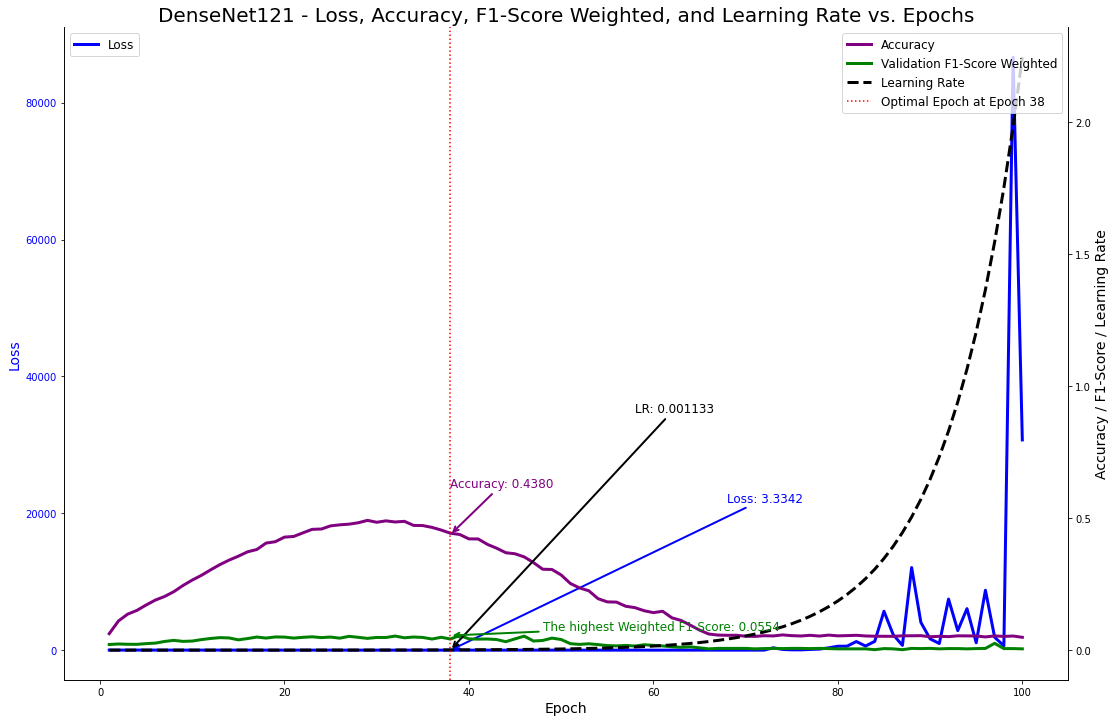

In [12]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 6. Display Learning Rate, Loss, Accuracy, and F1-Score Weighted all together across Epochs
display_lr_loss_accuracy_f1_across_epochs(history, model_name=model_name)

 #### Step 3: Analyze the Results and Identify the Optimal Learning Rate

 ### 5.3 MobileNetV2 - LR Range Test and Performance Analysis

 #### Step 1: Build and Train MobileNetV2 with Learning Rate Range Test

In [ ]:
%%time

model_name = 'MobileNetV2' 

# Initialize the model using the build_model function.
model = build_model(
    model_name=model_name,
    input_shape=in_shape_224,
    num_classes=NUM_CLASSES,
    unfreeze_last_layers_count=None  
)

# Calling the train_model_and_save function 
model, history = train_model_and_save(
    model=model,
    train_data=train_gen_224x224,   # The subset of training data
    val_data=valid_gen_224x224,     # The subset of validation data
    epochs=EPOCHS,                 
    batch_size=BATCH_SIZE,         
    class_weight_dict=class_weight_dict,  # Apply class weights 
    learning_rate=LEARNING_RATE,        # Learning rate
    model_name=model_name,              # The model name for saving
    save_model_dir=MODEL_DIR,           # Directory to save the model and checkpoints
    step_name=STEP_NAME,                # The current step name (e.g., 'Step2', 'Step3') for proper file naming
    lr_scheduler=lr_scheduler           # Apply the Learning Rate Scheduler
)


 #### Step 2: Plot Learning Rate vs. Loss, F1-Score Weighted, Accuracy

In [ ]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 6. Display Learning Rate, Loss, Accuracy, and F1-Score Weighted all together across Epochs
display_lr_loss_accuracy_f1_across_epochs(history, model_name=model_name)

#### Step 3: Analyze the Results and Identify the Optimal Learning Rate

 ### 5.4 InceptionResNetV2 - LR Range Test and Performance Analysis

#### Step 1: Build and Train InceptionResNetV2 with Learning Rate Range Test

In [ ]:
%%time

model_name = 'InceptionResNetV2' 

# Initialize the model using the build_model function.
model = build_model(
    model_name=model_name,
    input_shape=in_shape_299,
    num_classes=NUM_CLASSES,
    unfreeze_last_layers_count=None  
)

# Calling the train_model_and_save function 
model, history = train_model_and_save(
    model=model,
    train_data=train_gen_299x299,   # The subset of training data
    val_data=valid_gen_299x299,     # The subset of validation data
    epochs=EPOCHS,                 
    batch_size=BATCH_SIZE,         
    class_weight_dict=class_weight_dict,  # Apply class weights 
    learning_rate=LEARNING_RATE,        # Learning rate
    model_name=model_name,              # The model name for saving
    save_model_dir=MODEL_DIR,           # Directory to save the model and checkpoints
    step_name=STEP_NAME,                # The current step name (e.g., 'Step2', 'Step3') for proper file naming
    lr_scheduler=lr_scheduler           # Apply the Learning Rate Scheduler
)


 #### Step 2: Plot Learning Rate vs. Loss, F1-Score Weighted, Accuracy

In [ ]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 6. Display Learning Rate, Loss, Accuracy, and F1-Score Weighted all together across Epochs
display_lr_loss_accuracy_f1_across_epochs(history, model_name=model_name)

#### Step 3: Analyze the Results and Identify the Optimal Learning Rate

 ### 5.5 Xception - LR Range Test and Performance Analysis

#### Step 1: Build and Train Xception with Learning Rate Range Test

In [11]:
%%time

model_name = 'Xception' 

# Initialize the model using the build_model function.
model = build_model(
    model_name=model_name,
    input_shape=in_shape_299,
    num_classes=NUM_CLASSES,
    unfreeze_last_layers_count=None  
)

# Calling the train_model_and_save function 
model, history = train_model_and_save(
    model=model,
    train_data=train_gen_299x299,   # The subset of training data
    val_data=valid_gen_299x299,     # The subset of validation data
    epochs=EPOCHS,                 
    batch_size=BATCH_SIZE,         
    class_weight_dict=class_weight_dict,  # Apply class weights 
    learning_rate=LEARNING_RATE,        # Learning rate
    model_name=model_name,              # The model name for saving
    save_model_dir=MODEL_DIR,           # Directory to save the model and checkpoints
    step_name=STEP_NAME,                # The current step name (e.g., 'Step2', 'Step3') for proper file naming
    lr_scheduler=lr_scheduler           # Apply the Learning Rate Scheduler
)


[INFO] : Starting at epoch: 0, learning_rate: 9.999999747378752e-06
Epoch 1/100
213/213 [==============================] - ETA: 0s - loss: 16.8647 - accuracy: 0.0735
Epoch 1: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 96s 426ms/step - loss: 16.8647 - accuracy: 0.0735 - val_loss: 14.3928 - val_accuracy: 0.1378 - val_f1_score: 0.0204 - lr: 1.0000e-05
[INFO] : Learning rate updated from: 9.999999747378752e-06 to: 1.132541315152812e-05 at epoch 1
Epoch 2/100
213/213 [==============================] - ETA: 0s - loss: 15.8228 - accuracy: 0.1351
Epoch 2: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 97s 457ms/step - loss: 15.8228 - accuracy: 0.1351 - val_loss: 13.8852 - val_accuracy: 0.1564 - val_f1_score: 0.0147 - lr: 1.1325e-05
[INFO] : Learning rate updated from: 1.1325412742735352e-05 to: 1.2826498305280606e-05 at epoch 2
Epoch 3/100


[INFO] : Learning rate updated from: 6.468607898568735e-05 to: 7.325965428215231e-05 at epoch 16
Epoch 17/100
213/213 [==============================] - ETA: 0s - loss: 6.0356 - accuracy: 0.4346
Epoch 17: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 107s 504ms/step - loss: 6.0356 - accuracy: 0.4346 - val_loss: 5.2087 - val_accuracy: 0.4231 - val_f1_score: 0.0430 - lr: 7.3260e-05
[INFO] : Learning rate updated from: 7.325965270865709e-05 to: 8.29695852083491e-05 at epoch 17
Epoch 18/100
213/213 [==============================] - ETA: 0s - loss: 5.5449 - accuracy: 0.4423
Epoch 18: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 107s 504ms/step - loss: 5.5449 - accuracy: 0.4423 - val_loss: 4.7604 - val_accuracy: 0.4299 - val_f1_score: 0.0445 - lr: 8.2970e-05
[INFO] : Learning rate updated from: 8.296958549181e-05 to: 9.396648314954697e-05

[INFO] : Learning rate updated from: 0.00047388795064762235 to: 0.0005366976945540477 at epoch 32
Epoch 33/100
213/213 [==============================] - ETA: 0s - loss: 3.1293 - accuracy: 0.4543
Epoch 33: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 109s 513ms/step - loss: 3.1293 - accuracy: 0.4543 - val_loss: 2.5394 - val_accuracy: 0.4423 - val_f1_score: 0.0481 - lr: 5.3670e-04
[INFO] : Learning rate updated from: 0.0005366976838558912 to: 0.000607832312829723 at epoch 33
Epoch 34/100
213/213 [==============================] - ETA: 0s - loss: 3.1838 - accuracy: 0.4548
Epoch 34: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 109s 510ms/step - loss: 3.1838 - accuracy: 0.4548 - val_loss: 2.6978 - val_accuracy: 0.3934 - val_f1_score: 0.0387 - lr: 6.0783e-04
[INFO] : Learning rate updated from: 0.0006078323349356651 to: 0.000688395206964

213/213 [==============================] - ETA: 0s - loss: 4.0557 - accuracy: 0.3089
Epoch 49: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 108s 506ms/step - loss: 4.0557 - accuracy: 0.3089 - val_loss: 3.0432 - val_accuracy: 0.3369 - val_f1_score: 0.0352 - lr: 0.0039
[INFO] : Learning rate updated from: 0.003931828774511814 to: 0.004452958509942656 at epoch 49
Epoch 50/100
213/213 [==============================] - ETA: 0s - loss: 4.1534 - accuracy: 0.2928
Epoch 50: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 107s 501ms/step - loss: 4.1534 - accuracy: 0.2928 - val_loss: 2.9410 - val_accuracy: 0.3495 - val_f1_score: 0.0396 - lr: 0.0045
[INFO] : Learning rate updated from: 0.004452958703041077 to: 0.005043159487171359 at epoch 50
Epoch 51/100
213/213 [==============================] - ETA: 0s - loss: 4.2179 - accuracy: 0.2722
Epoch 5

213/213 [==============================] - ETA: 0s - loss: 361.0436 - accuracy: 0.0555
Epoch 81: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 109s 510ms/step - loss: 361.0436 - accuracy: 0.0555 - val_loss: 211.9699 - val_accuracy: 0.0595 - val_f1_score: 0.0067 - lr: 0.2110
[INFO] : Learning rate updated from: 0.2110203355550766 to: 0.2389892566231048 at epoch 81
Epoch 82/100
213/213 [==============================] - ETA: 0s - loss: 1022.0920 - accuracy: 0.0568
Epoch 82: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 109s 514ms/step - loss: 1022.0920 - accuracy: 0.0568 - val_loss: 389.8911 - val_accuracy: 0.0506 - val_f1_score: 0.0049 - lr: 0.2390
[INFO] : Learning rate updated from: 0.23898926377296448 to: 0.27066520700332414 at epoch 82
Epoch 83/100
213/213 [==============================] - ETA: 0s - loss: 264.5132 - accuracy: 0.05

213/213 [==============================] - ETA: 0s - loss: 80284.9531 - accuracy: 0.0529
Epoch 97: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 108s 506ms/step - loss: 80284.9531 - accuracy: 0.0529 - val_loss: 58717.1250 - val_accuracy: 0.0559 - val_f1_score: 0.0059 - lr: 1.5459
[INFO] : Learning rate updated from: 1.5459277629852295 to: 1.7508270317357235 at epoch 97
Epoch 98/100
213/213 [==============================] - ETA: 0s - loss: 32086.8145 - accuracy: 0.0528
Epoch 98: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 108s 509ms/step - loss: 32086.8145 - accuracy: 0.0528 - val_loss: 16459.3691 - val_accuracy: 0.0595 - val_f1_score: 0.0067 - lr: 1.7508
[INFO] : Learning rate updated from: 1.7508270740509033 to: 1.9828839491270713 at epoch 98
Epoch 99/100
213/213 [==============================] - ETA: 0s - loss: 9689.6631 - accur

 #### Step 2: Visualizing the Learning Rate, Loss, Accuracy, and F1-Score for Model: Xception across Epochs

 ##### Load Xception Training History - Optional

In [41]:
import pickle
import pandas as pd

from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *
importlib.reload(config)  # Reload config to ensure any updates are applied


model_name = 'Xception' 

# Define the path to the saved history file
history_filepath = MODEL_DIR / 'Step4_Xception_history.pkl'

# Load the training history from the .pkl file
with open(history_filepath, 'rb') as history_file:
    saved_history = pickle.load(history_file)

# Convert the history dictionary to a pandas DataFrame for easier display
history_df = pd.DataFrame(saved_history)

# Vérifier les clés de l'historique chargé
print("Keys in the loaded history:", saved_history.keys())

# Display the shape of the history DataFrame
print('\nShape of the history DataFrame:')
print(history_df.shape)

# Display the first 10 rows of the history
print('\nDisplaying the first rows of the history:')
print(history_df.head(5))

# Display the last  rows of the history
print('\nDisplaying the first rows of the history:')
print(history_df.tail(5))

# Define the new file path for saving the history as a CSV file
csv_history_filepath = MODEL_DIR / f'Step4_{model_name}_history.csv'

# Save the DataFrame as a CSV file
history_df.to_csv(csv_history_filepath, index=False)

print(f'\nHistory saved as CSV at: {csv_history_filepath}')


# Create a dummy object that has a 'history' attribute to mimic the history object from model training
class History:
    def __init__(self, history_dict):
        self.history = history_dict

# Convert the dictionary into an object with 'history' as an attribute
history = History(saved_history)

# # Now, you can call the display function with the history object
# display_f1score_lr(history, model_name="model_name")


Keys in the loaded history: Index(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'val_f1_score', 'lr'], dtype='object')

Shape of the history DataFrame:
(100, 6)

Displaying the first rows of the history:
        loss  accuracy   val_loss  val_accuracy  val_f1_score        lr
0  16.864700  0.073458  14.392811      0.137809      0.020363  0.000010
1  15.822760  0.135139  13.885180      0.156360      0.014672  0.000011
2  14.951148  0.154792  13.308824      0.170495      0.014086  0.000013
3  14.182961  0.174076  12.695696      0.184923      0.021428  0.000015
4  13.471754  0.197483  12.083248      0.220554      0.026303  0.000016

Displaying the first rows of the history:
            loss  accuracy      val_loss  val_accuracy  val_f1_score        lr
95    466.435516  0.054321    381.523102      0.050648      0.004883  1.365008
96  80284.953125  0.052922  58717.125000      0.055948      0.005929  1.545928
97  32086.814453  0.052775  16459.369141      0.059482      0.006679  1.750827
98

##### Display Learning Rate across epochs

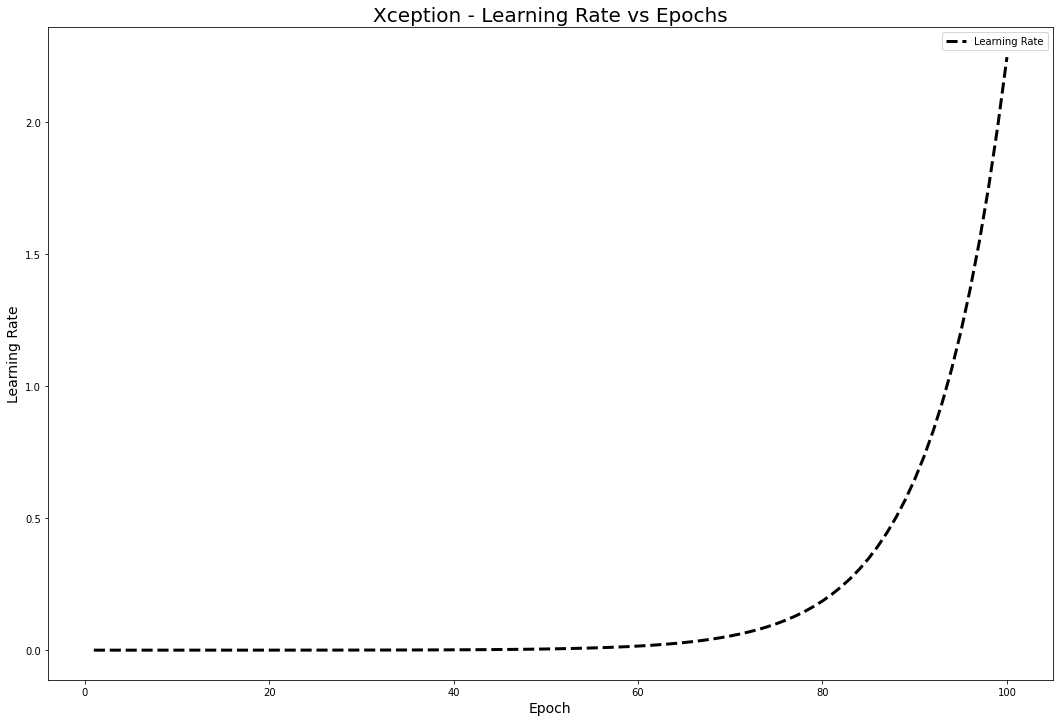

In [55]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 1. Display Learning Rate across Epochs
display_learning_rate_across_epochs(history, model_name=model_name)

##### Display Loss across epochs

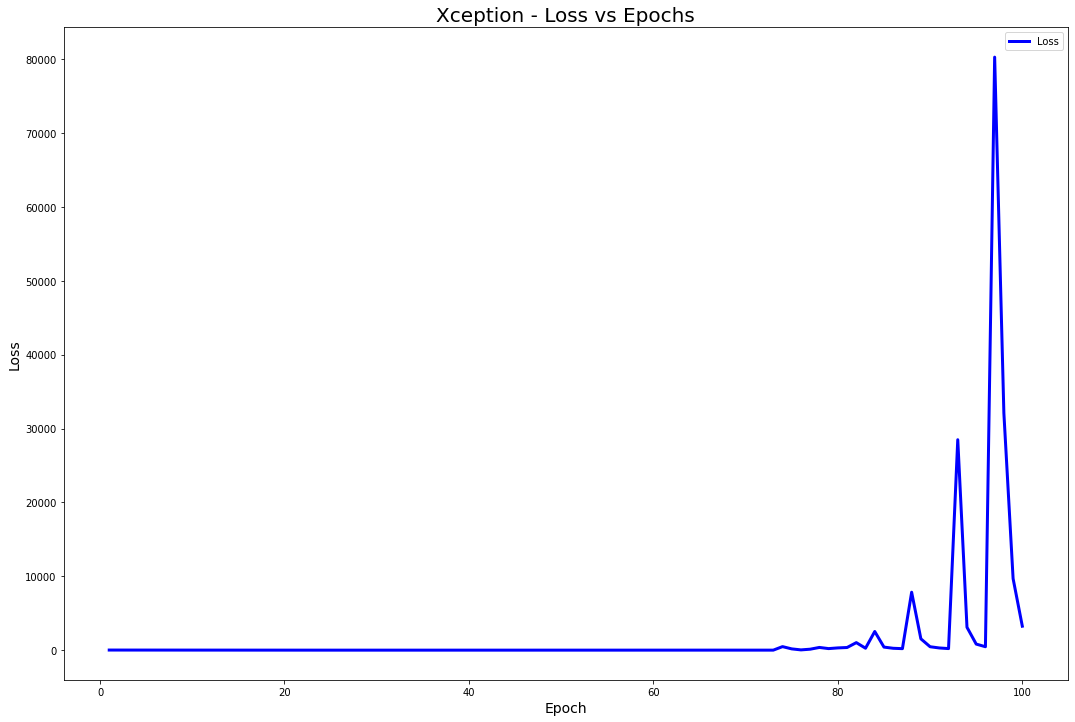

In [56]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 2. Display Loss across Epochs
display_loss_across_epochs(history, model_name=model_name)

##### Display Accuracy across epochs

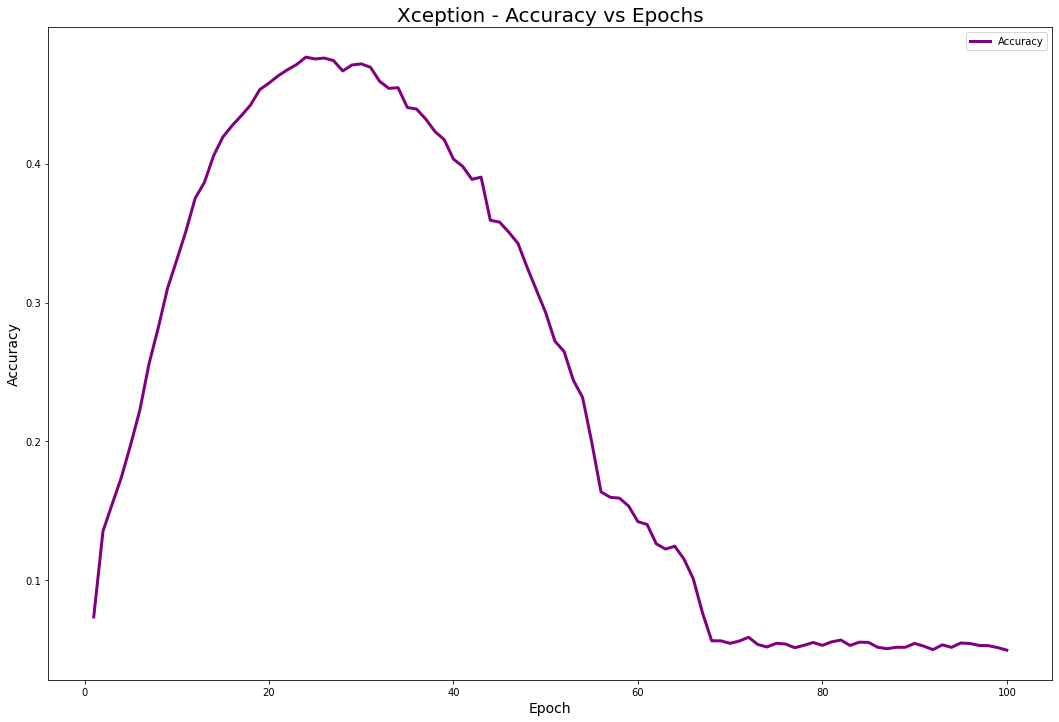

In [57]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 3. Display Accuracy across Epochs
display_accuracy_across_epochs(history, model_name=model_name)

##### Display Validation F1-Score weighted across epochs

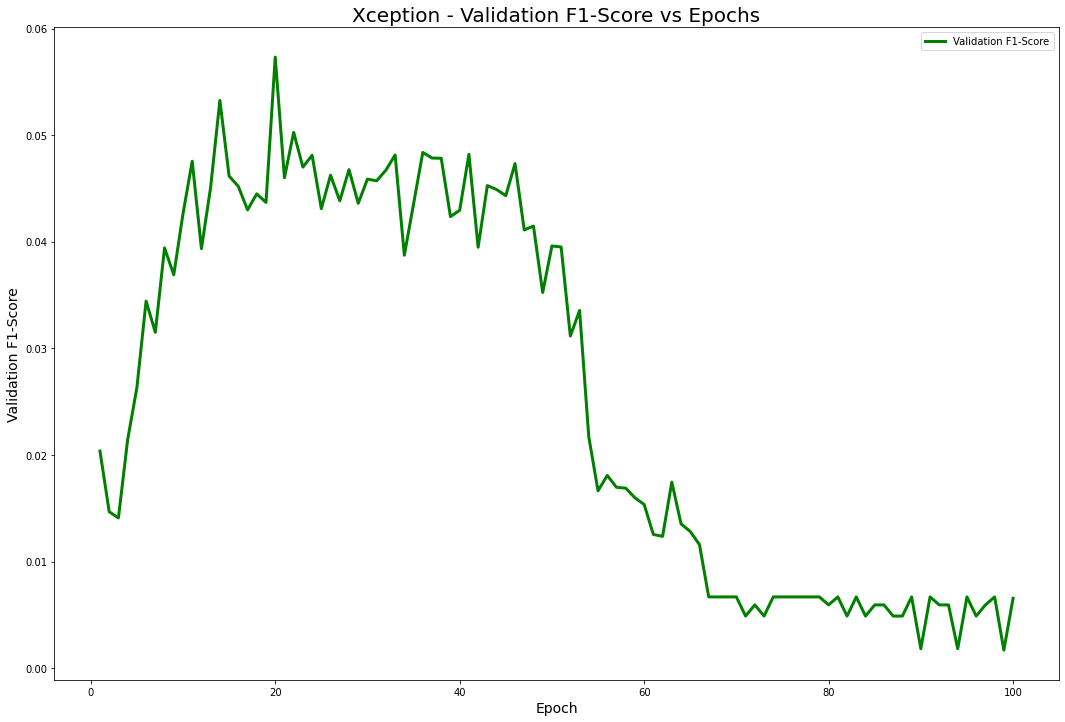

In [58]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 4. Display Validation F1-Score Weighted across Epochs
display_val_f1_score_across_epochs(history, model_name=model_name)

#####  Learning Rate Vs Validation F1-Score

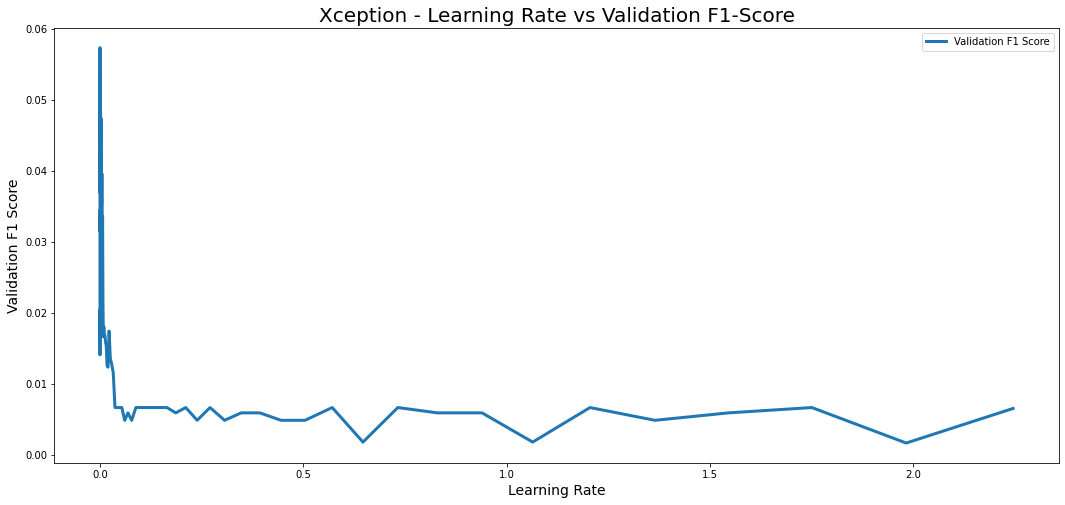

In [66]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 6.  the Learning Rate vs Validation F1-Score across epochs.
display_lr_vs_val_f1_score(history, model_name=model_name)

##### Display Learning Rate, Loss, Accuracy, and F1-Score Weighted across epochs

In [156]:
# Display the first 10 rows of the history
print('\nDisplaying the first rows of the history:')
print(history_df.head(2))
print(history_df.tail(2))
# Définir les index de début et fin
i = 15  # Index de début
j = 25  # Index de fin

# Afficher les lignes entre i et j (i inclus, j exclus)
print(f"\nValeurs du DataFrame entre les index {i} et {j} :")
print(history_df.iloc[i:j])




Displaying the first rows of the history:
        loss  accuracy   val_loss  val_accuracy  val_f1_score        lr
0  16.929491  0.076181  14.558347      0.138693      0.014494  0.000010
1  16.007729  0.131091  14.149946      0.146938      0.017243  0.000011
            loss  accuracy      val_loss  val_accuracy  val_f1_score        lr
98  47747.207031  0.053364  36900.898438      0.059482      0.006679  1.982884
99  29890.558594  0.049904  24292.101562      0.055948      0.005929  2.245698

Valeurs du DataFrame entre les index 15 et 25 :
        loss  accuracy  val_loss  val_accuracy  val_f1_score        lr
15  8.007872  0.423377  7.151870      0.404005      0.050450  0.000065
16  7.477652  0.431547  6.637044      0.413428      0.046803  0.000073
17  6.957059  0.442662  6.133772      0.434040      0.047013  0.000083
18  6.442035  0.451200  5.698940      0.430212      0.043951  0.000094
19  5.972344  0.459959  5.208460      0.443463      0.047140  0.000106
20  5.476066  0.471588  4.801

Y-axis range for Loss 3.1937320232391357 to 776901.75
Y-axis range for Loss - loss_scale 388449.2781339884


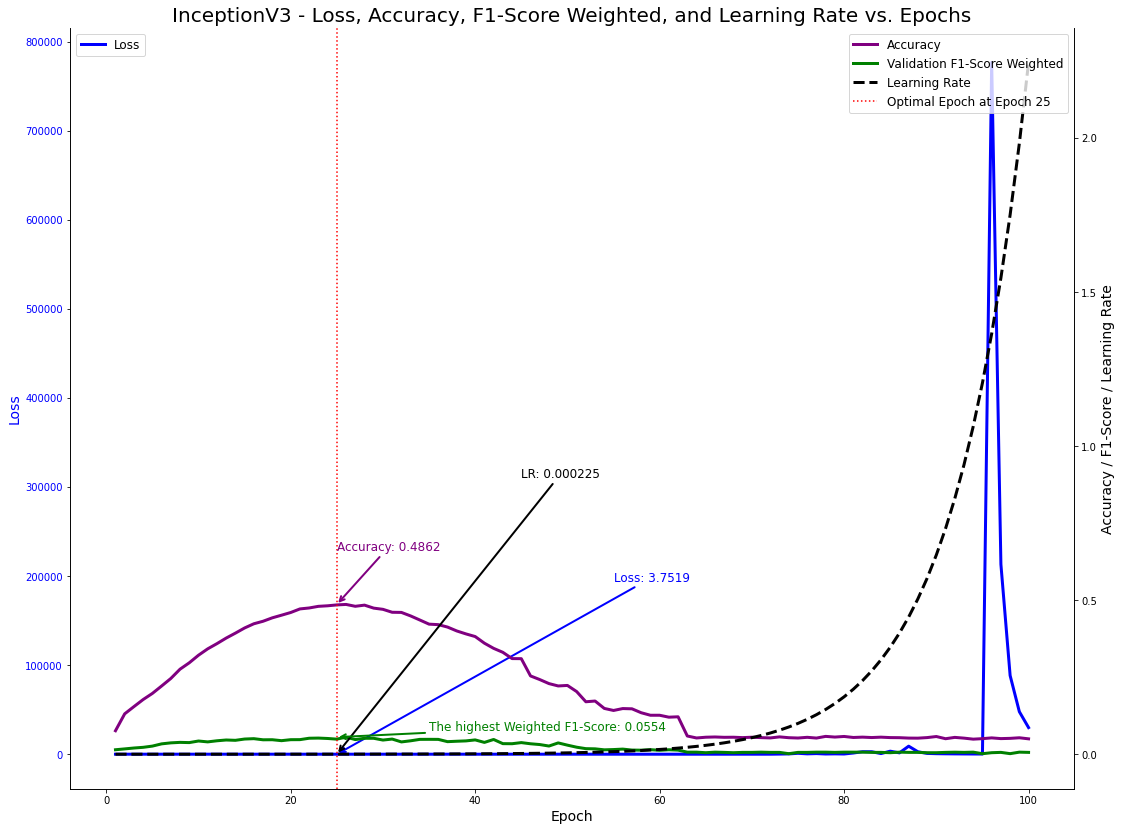

In [155]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 6. Display Learning Rate, Loss, Accuracy, and F1-Score Weighted all together across Epochs
display_lr_loss_accuracy_f1_across_epochs(history, model_name=model_name)

 #### Step 3: Analyze the Results and Identify the Optimal Learning Rate

### Analysis of the Graph: Loss, Accuracy, F1-Score Weighted, and Learning Rate vs Epochs

Based on the analysis of the **Loss, Accuracy, F1-Score Weighted, and Learning Rate vs Epochs** graph, we have applied annotations to highlight the following key points:

### Graph Analysis and Annotations

- **Annotations on Graph**: The **Highest Weighted F1-Score** (highlighted in green) has been annotated along with its corresponding **Loss**, **Learning Rate**, and **Epoch** values. 
- **Stability of Curves around the Highest F1-Score**: Before and after reaching the highest **F1-Score**, the **Loss**, **Accuracy**, and **Learning Rate** curves remain stable, showing no significant fluctuations. This indicates that the model is converging correctly without any major issues during this phase.
- **Post-Optimal Stability and Instability**: After a certain point, as the **Learning Rate** increases significantly, the **Loss** curve becomes more volatile, displaying large fluctuations and instability.
- **Conclusion**: Based on the stable region around the **Highest F1-Score**, the **optimal Learning Rate** for the Xception model in our case study appears to be around **0.000106**.

### Note:
- We used **20% of our dataset for training**, which may influence the results. Training on the full dataset could potentially lead to a more refined optimal value.


---

 ### 5.6 InceptionV3 - LR Range Test and Performance Analysis

#### Step 1: Build and Train InceptionV3 with Learning Rate Range Test

In [16]:
%%time

model_name = 'InceptionV3' 

# Initialize the model using the build_model function.
model = build_model(
    model_name=model_name,
    input_shape=in_shape_299,
    num_classes=NUM_CLASSES,
    unfreeze_last_layers_count=None  
)

# Calling the train_model_and_save function 
model, history = train_model_and_save(
    model=model,
    train_data=train_gen_299x299,   # The subset of training data
    val_data=valid_gen_299x299,     # The subset of validation data
    epochs=EPOCHS,                 
    batch_size=BATCH_SIZE,         
    class_weight_dict=class_weight_dict,  # Apply class weights 
    learning_rate=LEARNING_RATE,        # Learning rate
    model_name=model_name,              # The model name for saving
    save_model_dir=MODEL_DIR,           # Directory to save the model and checkpoints
    step_name=STEP_NAME,                # The current step name (e.g., 'Step2', 'Step3') for proper file naming
    lr_scheduler=lr_scheduler           # Apply the Learning Rate Scheduler
)


[INFO] : Starting at epoch: 0, learning_rate: 9.999999747378752e-06
Epoch 1/100
213/213 [==============================] - ETA: 0s - loss: 16.9295 - accuracy: 0.0762
Epoch 1: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 93s 416ms/step - loss: 16.9295 - accuracy: 0.0762 - val_loss: 14.5583 - val_accuracy: 0.1387 - val_f1_score: 0.0145 - lr: 1.0000e-05
[INFO] : Learning rate updated from: 9.999999747378752e-06 to: 1.132541315152812e-05 at epoch 1
Epoch 2/100
213/213 [==============================] - ETA: 0s - loss: 16.0077 - accuracy: 0.1311
Epoch 2: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 88s 415ms/step - loss: 16.0077 - accuracy: 0.1311 - val_loss: 14.1499 - val_accuracy: 0.1469 - val_f1_score: 0.0172 - lr: 1.1325e-05
[INFO] : Learning rate updated from: 1.1325412742735352e-05 to: 1.2826498305280606e-05 at epoch 2
Epoch 3/100


[INFO] : Learning rate updated from: 6.468607898568735e-05 to: 7.325965428215231e-05 at epoch 16
Epoch 17/100
213/213 [==============================] - ETA: 0s - loss: 7.4777 - accuracy: 0.4315
Epoch 17: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 92s 432ms/step - loss: 7.4777 - accuracy: 0.4315 - val_loss: 6.6370 - val_accuracy: 0.4134 - val_f1_score: 0.0468 - lr: 7.3260e-05
[INFO] : Learning rate updated from: 7.325965270865709e-05 to: 8.29695852083491e-05 at epoch 17
Epoch 18/100
213/213 [==============================] - ETA: 0s - loss: 6.9571 - accuracy: 0.4427
Epoch 18: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 92s 430ms/step - loss: 6.9571 - accuracy: 0.4427 - val_loss: 6.1338 - val_accuracy: 0.4340 - val_f1_score: 0.0470 - lr: 8.2970e-05
[INFO] : Learning rate updated from: 8.296958549181e-05 to: 9.396648314954697e-05 a

[INFO] : Learning rate updated from: 0.00047388795064762235 to: 0.0005366976945540477 at epoch 32
Epoch 33/100
213/213 [==============================] - ETA: 0s - loss: 3.2288 - accuracy: 0.4488
Epoch 33: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 92s 430ms/step - loss: 3.2288 - accuracy: 0.4488 - val_loss: 2.7996 - val_accuracy: 0.3843 - val_f1_score: 0.0435 - lr: 5.3670e-04
[INFO] : Learning rate updated from: 0.0005366976838558912 to: 0.000607832312829723 at epoch 33
Epoch 34/100
213/213 [==============================] - ETA: 0s - loss: 3.2621 - accuracy: 0.4356
Epoch 34: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 92s 430ms/step - loss: 3.2621 - accuracy: 0.4356 - val_loss: 2.7241 - val_accuracy: 0.4134 - val_f1_score: 0.0482 - lr: 6.0783e-04
[INFO] : Learning rate updated from: 0.0006078323349356651 to: 0.00068839520696455

213/213 [==============================] - ETA: 0s - loss: 4.1893 - accuracy: 0.2216
Epoch 49: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 92s 434ms/step - loss: 4.1893 - accuracy: 0.2216 - val_loss: 3.1238 - val_accuracy: 0.2568 - val_f1_score: 0.0367 - lr: 0.0039
[INFO] : Learning rate updated from: 0.003931828774511814 to: 0.004452958509942656 at epoch 49
Epoch 50/100
213/213 [==============================] - ETA: 0s - loss: 4.2710 - accuracy: 0.2232
Epoch 50: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 92s 433ms/step - loss: 4.2710 - accuracy: 0.2232 - val_loss: 3.1226 - val_accuracy: 0.2391 - val_f1_score: 0.0294 - lr: 0.0045
[INFO] : Learning rate updated from: 0.004452958703041077 to: 0.005043159487171359 at epoch 50
Epoch 51/100
213/213 [==============================] - ETA: 0s - loss: 4.3471 - accuracy: 0.2034
Epoch 51:

213/213 [==============================] - ETA: 0s - loss: 1338.2930 - accuracy: 0.0543
Epoch 81: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 92s 434ms/step - loss: 1338.2930 - accuracy: 0.0543 - val_loss: 663.3500 - val_accuracy: 0.0595 - val_f1_score: 0.0067 - lr: 0.2110
[INFO] : Learning rate updated from: 0.2110203355550766 to: 0.2389892566231048 at epoch 81
Epoch 82/100
213/213 [==============================] - ETA: 0s - loss: 2807.7053 - accuracy: 0.0554
Epoch 82: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 92s 432ms/step - loss: 2807.7053 - accuracy: 0.0554 - val_loss: 1294.7805 - val_accuracy: 0.0595 - val_f1_score: 0.0067 - lr: 0.2390
[INFO] : Learning rate updated from: 0.23898926377296448 to: 0.27066520700332414 at epoch 82
Epoch 83/100
213/213 [==============================] - ETA: 0s - loss: 2774.5142 - accuracy: 0.

213/213 [==============================] - ETA: 0s - loss: 213273.2812 - accuracy: 0.0506
Epoch 97: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 92s 430ms/step - loss: 213273.2812 - accuracy: 0.0506 - val_loss: 127029.2109 - val_accuracy: 0.0559 - val_f1_score: 0.0059 - lr: 1.5459
[INFO] : Learning rate updated from: 1.5459277629852295 to: 1.7508270317357235 at epoch 97
Epoch 98/100
213/213 [==============================] - ETA: 0s - loss: 88359.3125 - accuracy: 0.0515
Epoch 98: Evaluating model performance on validation data... Computing weighted F1 score.
213/213 [==============================] - 92s 431ms/step - loss: 88359.3125 - accuracy: 0.0515 - val_loss: 62243.7578 - val_accuracy: 0.0306 - val_f1_score: 0.0018 - lr: 1.7508
[INFO] : Learning rate updated from: 1.7508270740509033 to: 1.9828839491270713 at epoch 98
Epoch 99/100
213/213 [==============================] - ETA: 0s - loss: 47747.2070 - acc

#### Step 2: Visualizing the Learning Rate, Loss, Accuracy, and F1-Score for Model: InceptionV3 across Epochs

In [ ]:
 ##### Load InceptionV3 Training History - Optional

In [144]:
 import pickle
import pandas as pd

from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *
importlib.reload(config)  # Reload config to ensure any updates are applied


model_name = 'InceptionV3' 

# Define the path to the saved history file
history_filepath = MODEL_DIR / f'Step4_{model_name}_history.pkl'

# Load the training history from the .pkl file
with open(history_filepath, 'rb') as history_file:
    saved_history = pickle.load(history_file)

# Convert the history dictionary to a pandas DataFrame for easier display
history_df = pd.DataFrame(saved_history)

# Vérifier les clés de l'historique chargé
print("Keys in the loaded history:", saved_history.keys())

# Display the shape of the history DataFrame
print('\nShape of the history DataFrame:')
print(history_df.shape)

# Display the first 10 rows of the history
print('\nDisplaying the first rows of the history:')
print(history_df.head(5))

# Display the last  rows of the history
print('\nDisplaying the first rows of the history:')
print(history_df.tail(5))

# Define the new file path for saving the history as a CSV file
csv_history_filepath = MODEL_DIR / f'Step4_{model_name}_history.csv'

# Save the DataFrame as a CSV file
history_df.to_csv(csv_history_filepath, index=False)

print(f'\nHistory saved as CSV at: {csv_history_filepath}')


# Create a dummy object that has a 'history' attribute to mimic the history object from model training
class History:
    def __init__(self, history_dict):
        self.history = history_dict

# Convert the dictionary into an object with 'history' as an attribute
history = History(saved_history)

# # Now, you can call the display function with the history object
# display_f1score_lr(history, model_name="model_name")

Keys in the loaded history: Index(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'val_f1_score', 'lr'], dtype='object')

Shape of the history DataFrame:
(100, 6)

Displaying the first rows of the history:
        loss  accuracy   val_loss  val_accuracy  val_f1_score        lr
0  16.929491  0.076181  14.558347      0.138693      0.014494  0.000010
1  16.007729  0.131091  14.149946      0.146938      0.017243  0.000011
2  15.328117  0.154497  13.704890      0.166372      0.020116  0.000013
3  14.737079  0.177462  13.251319      0.185807      0.022338  0.000015
4  14.169971  0.197335  12.767711      0.211720      0.026326  0.000016

Displaying the first rows of the history:
             loss  accuracy       val_loss  val_accuracy  val_f1_score  \
95  776901.750000  0.052996  360078.281250      0.050648      0.004883   
96  213273.281250  0.050640  127029.210938      0.055948      0.005929   
97   88359.312500  0.051450   62243.757812      0.030624      0.001820   
98   47747.207031  0.0

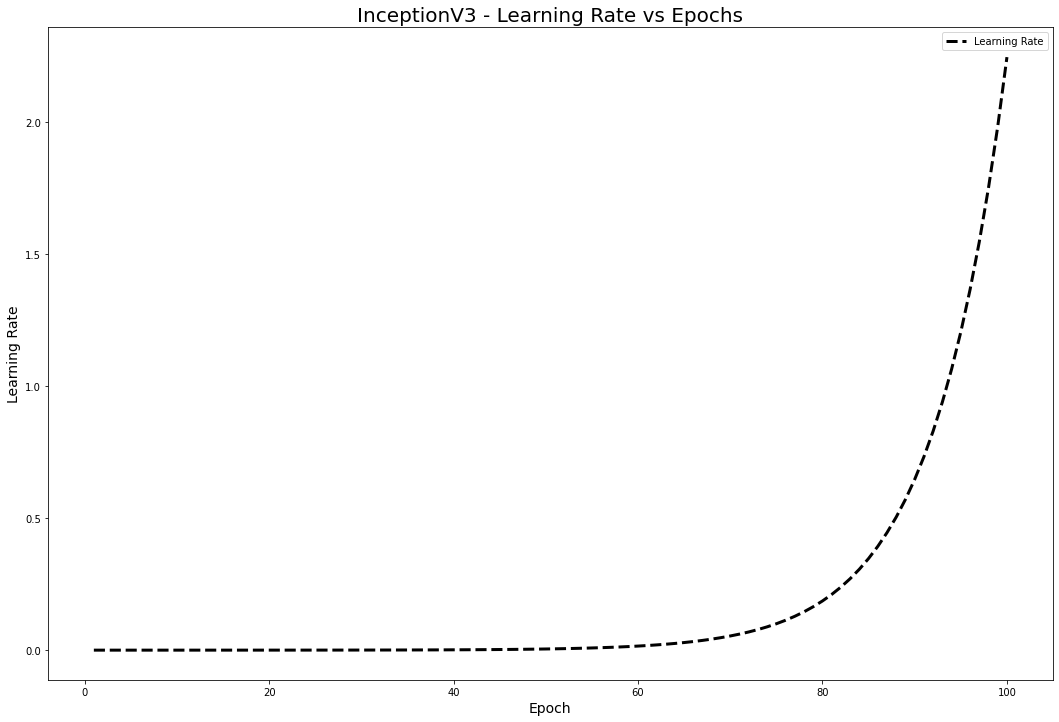

In [145]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 1. Display Learning Rate across Epochs
display_learning_rate_across_epochs(history, model_name=model_name)

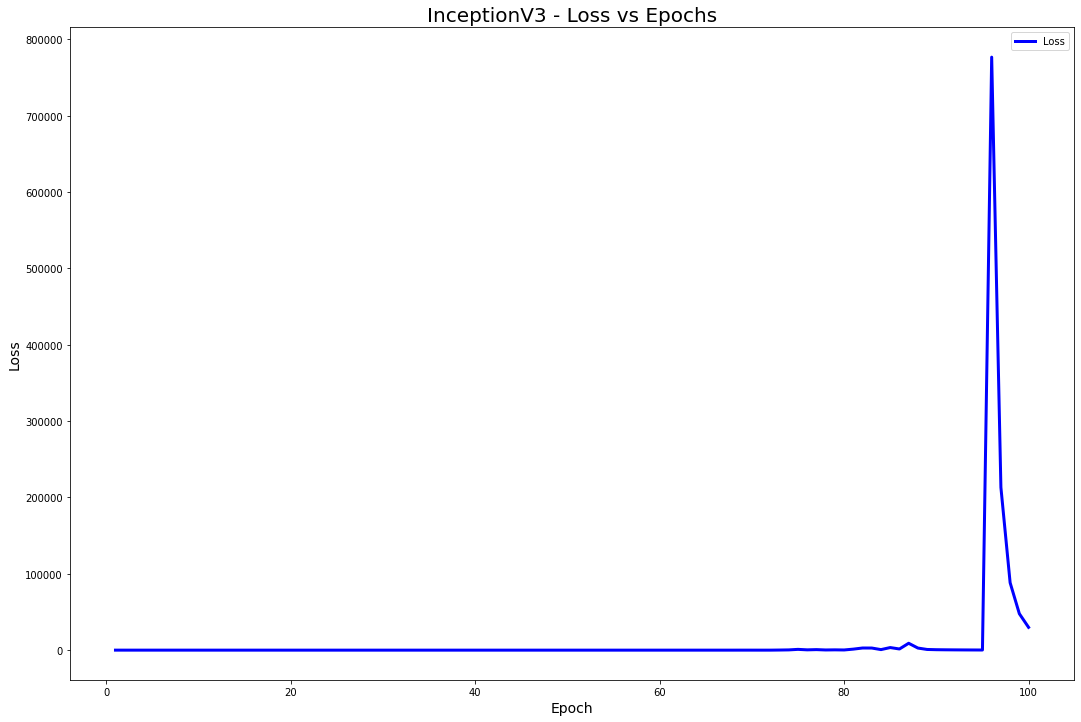

In [146]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 2. Display Loss across Epochs
display_loss_across_epochs(history, model_name=model_name)

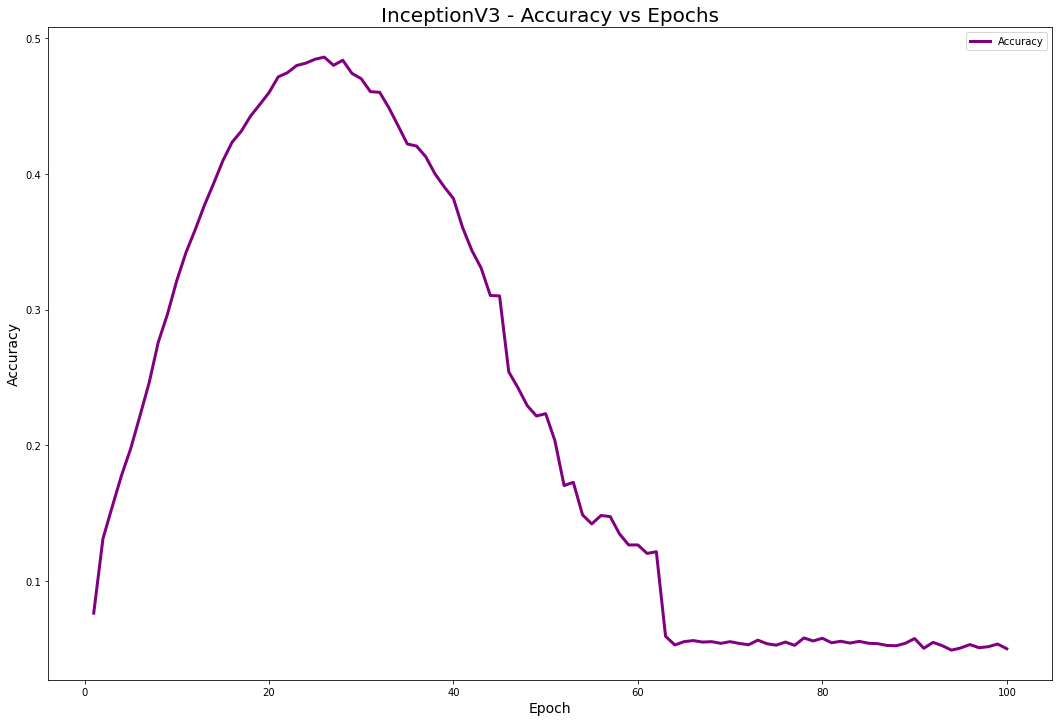

In [147]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 3. Display Accuracy across Epochs
display_accuracy_across_epochs(history, model_name=model_name)


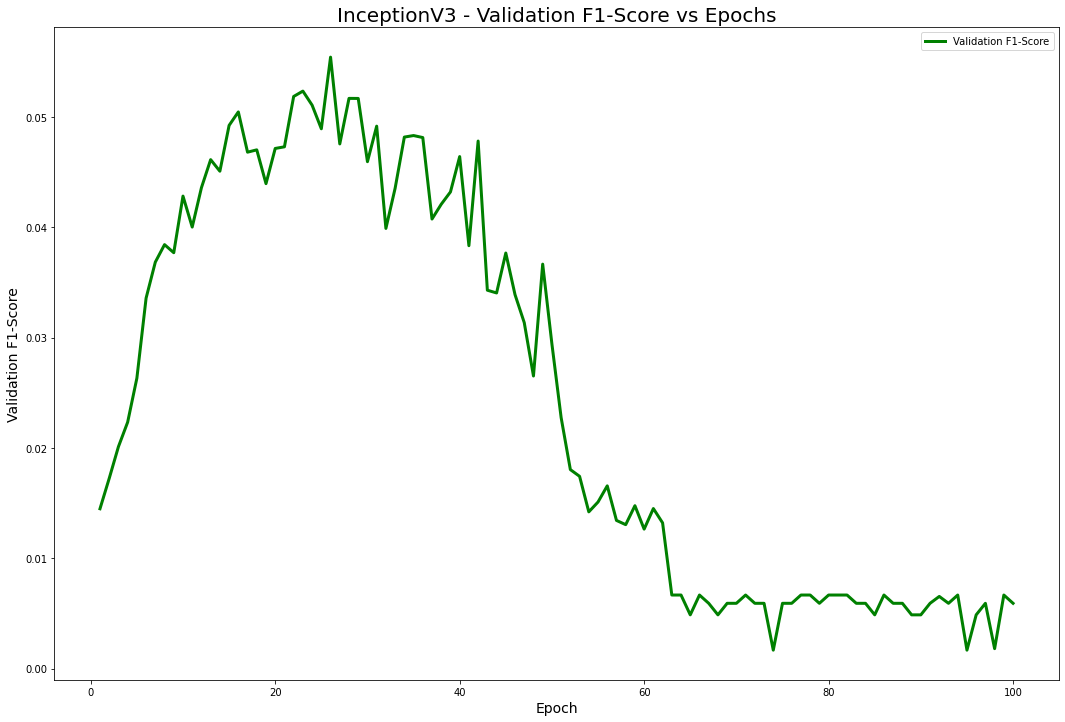

In [148]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 4. Display Validation F1-Score Weighted across Epochs
display_val_f1_score_across_epochs(history, model_name=model_name)


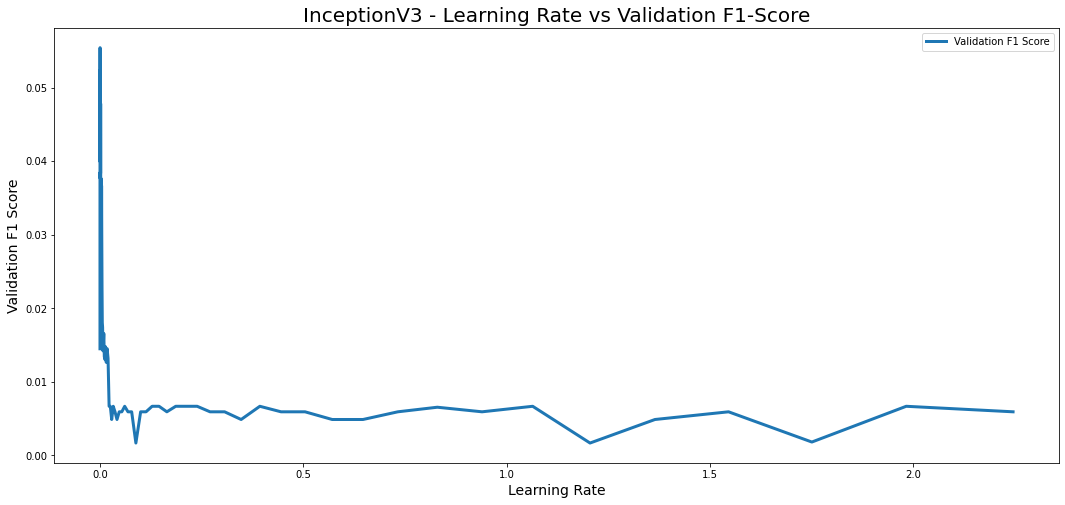

In [149]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 6.  the Learning Rate vs Validation F1-Score across epochs.
display_lr_vs_val_f1_score(history, model_name=model_name)

In [153]:
# Display the first 10 rows of the history
print('\nDisplaying the first rows of the history:')
print(history_df.head(2))
print(history_df.tail(2))
# Définir les index de début et fin
i = 20  # Index de début
j = 30  # Index de fin

# Afficher les lignes entre i et j (i inclus, j exclus)
print(f"\nValeurs du DataFrame entre les index {i} et {j} :")
print(history_df.iloc[i:j])



Displaying the first rows of the history:
        loss  accuracy   val_loss  val_accuracy  val_f1_score        lr
0  16.929491  0.076181  14.558347      0.138693      0.014494  0.000010
1  16.007729  0.131091  14.149946      0.146938      0.017243  0.000011
            loss  accuracy      val_loss  val_accuracy  val_f1_score        lr
98  47747.207031  0.053364  36900.898438      0.059482      0.006679  1.982884
99  29890.558594  0.049904  24292.101562      0.055948      0.005929  2.245698

Valeurs du DataFrame entre les index 20 et 30 :
        loss  accuracy  val_loss  val_accuracy  val_f1_score        lr
20  5.476066  0.471588  4.801549      0.444935      0.047288  0.000121
21  5.050867  0.474680  4.357802      0.454064      0.051849  0.000137
22  4.655874  0.479979  4.052551      0.449352      0.052336  0.000155
23  4.301237  0.481746  3.664561      0.469376      0.051061  0.000175
24  4.010447  0.484617  3.401703      0.466726      0.048921  0.000198
25  3.751864  0.486162  3.265

Y-axis range for Loss 3.1937320232391357 to 776901.75
Y-axis range for Loss - loss_scale 388449.2781339884


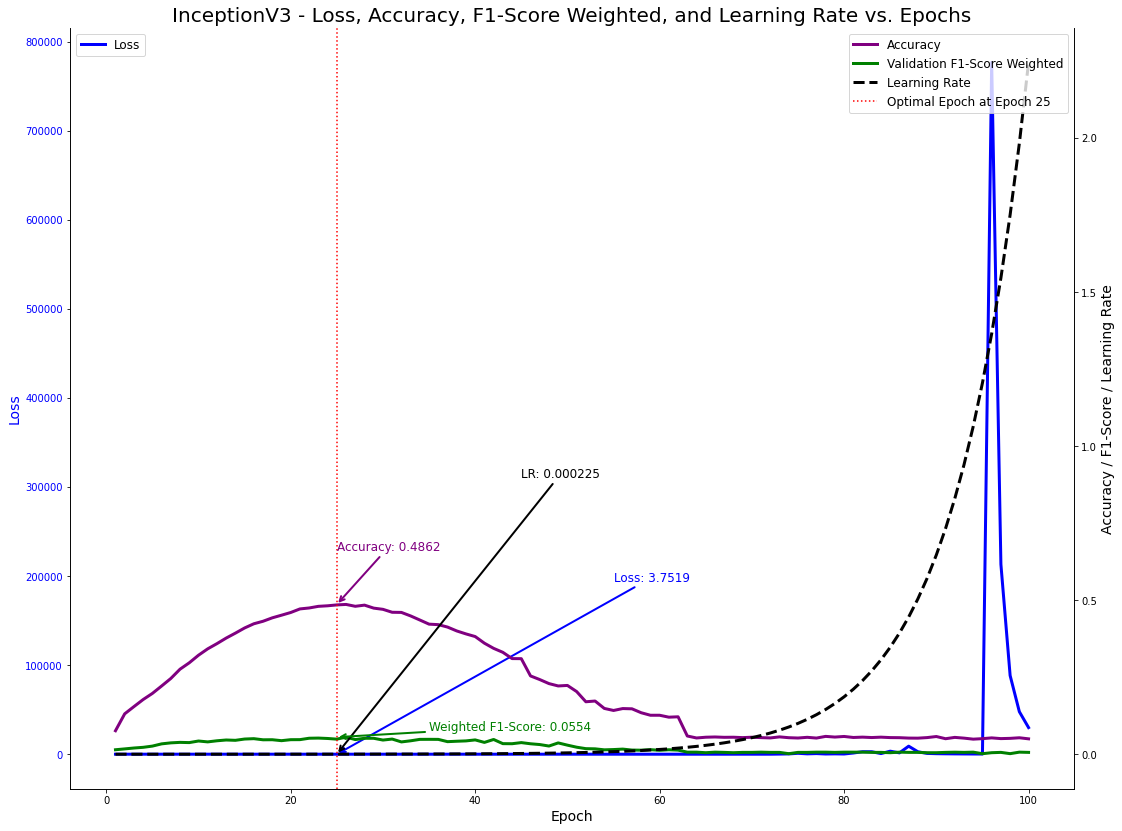

In [152]:
from src.modeling_image.lr_optimization import *
importlib.reload(src.modeling_image.lr_optimization)
from src.modeling_image.lr_optimization import *

# 6. Display Learning Rate, Loss, Accuracy, and F1-Score Weighted all together across Epochs
display_lr_loss_accuracy_f1_across_epochs(history, model_name=model_name)

#### Step 3: Analyze the Results and Identify the Optimal Learning Rate

### Analysis of the Graph: Loss, Accuracy, F1-Score Weighted, and Learning Rate vs Epochs for **InceptionV3**

Based on the graph showing the **Loss**, **Accuracy**, **F1-Score Weighted**, and **Learning Rate** against **Epochs** for the **InceptionV3** model, we can derive the following insights:

### Graph Analysis and Annotations

- **Annotations on Graph**: The graph displays the **Highest Weighted F1-Score** (in green), the **Accuracy** (in purple), and the **Learning Rate** (in black, dashed), with corresponding values annotated. The **Epoch** corresponding to the highest **F1-Score** is indicated by the vertical red line.
  
- **Stability Before the Highest F1-Score**: Before reaching the point of maximum **F1-Score**, we notice that the **Loss**, **Accuracy**, and **Learning Rate** curves remain relatively stable. This stability suggests that the model is learning steadily without large fluctuations in these metrics.

- **Post-Peak Instability**: After the highest point, the **Loss** curve starts to increase rapidly, with noticeable volatility as the **Learning Rate** rises. This increased volatility, seen in both the **Loss** and **Accuracy** curves, indicates that further increasing the learning rate is causing the model to become unstable.

- **Conclusion**: From this graph, we conclude that the **optimal learning rate** for **InceptionV3** in our dataset appears to be around **0.000225**, which corresponds to the stable region before the learning rate increases significantly and causes instability in the loss and accuracy curves.

### Key Notes:
- We have used only **20% of our training dataset**, which might influence the result. Training with a larger dataset could provide a more accurate optimal learning rate.


---

---

# 6. Results and Next Steps

## Learning Rate Optimization Results

In this step, we have optimized the learning rate for each of the top-performing models, including **MobileNetV2**, **DenseNet121**, **InceptionResNetV2**, **Xception**, and **InceptionV3**. After analyzing the **F1-Score Weighted** and the corresponding loss, we identified the best learning rates for each model. Below are the results:

- **DenseNet121**: Best Learning Rate = **[0.001133]**
- **MobileNetV2**: Best Learning Rate = **[insert best LR here]**
- **InceptionResNetV2**: Best Learning Rate = **[insert best LR here]**
- **Xception**: Best Learning Rate = **[0.000106]**
- **InceptionV3**: Best Learning Rate = **[0.000225]**

### Next Step: Notebook 21 - Final Tuning

In the next notebook, `21_Image_Final_Tuning.ipynb`, we will proceed with the following steps:

1. **Training**: We will train all 5 models using the optimized learning rates obtained during the learning rate optimization step.
2. **Data Augmentation**: Data augmentation will be applied to further improve model generalization.
3. **Fine-Tuning**: We will unfreeze some of the last layers of the pre-trained models and fine-tune them using the optimized learning rates.
4. **Evaluation**: Finally, we will evaluate the models using the **F1-Score Weighted** to determine their performance on the validation set and identify the best-performing model.

By the end of this process, we aim to have the most optimized models ready for final deployment and further improvements.
